---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("="*70)
print("ADAMSENSE DATA EXPLORATION")
print("Wrist-Worn Activity Recognition")
print("="*70)
print("\n✓ Libraries loaded successfully")

ADAMSENSE DATA EXPLORATION
Wrist-Worn Activity Recognition

✓ Libraries loaded successfully


---
## Step 2: Configuration - UPDATE THIS PATH!

In [2]:
# ============================================================================
# CONFIGURATION - UPDATE THIS PATH!
# ============================================================================

DATASET_PATH = '../data/raw/AdamSense.csv'  

# Output directory for figures
OUTPUT_DIR = './exploration_outputs/'

# ============================================================================

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Output:  {OUTPUT_DIR}")
print(f"\n✓ Configuration complete")

Configuration:
  Dataset: ../data/raw/AdamSense.csv
  Output:  ./exploration_outputs/

✓ Configuration complete


---
## Step 3: Load AdamSense Dataset

In [3]:
print("="*70)
print("LOADING ADAMSENSE DATASET")
print("="*70)

if not Path(DATASET_PATH).exists():
    print("\nPlease update DATASET_PATH in Step 2.")
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}")

print(f"\nLoading: {DATASET_PATH}")
df = pd.read_csv(DATASET_PATH)

print(f"\n✓ Dataset loaded successfully!")
print(f"\nBasic Info:")
print(f"  Total samples: {len(df):,}")
print(f"  Total columns: {len(df.columns)}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print(f"\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

LOADING ADAMSENSE DATASET

Loading: ../data/raw/AdamSense.csv

✓ Dataset loaded successfully!

Basic Info:
  Total samples: 709,582
  Total columns: 26
  Memory usage: 264.5 MB

All columns:
   1. Activity
   2. Ax_p
   3. Ax_w
   4. Ay_p
   5. Ay_w
   6. Az_p
   7. Az_w
   8. GPS1_p
   9. GPS2_p
  10. Gx_p
  11. Gx_w
  12. Gy_p
  13. Gy_w
  14. Gz_p
  15. Gz_w
  16. Mx_p
  17. Mx_w
  18. My_p
  19. My_w
  20. Mz_p
  21. Mz_w
  22. PocketDev
  23. Time_p
  24. Time_w
  25. User
  26. WristDev


---
## Step 4: Identify Wrist Sensor Columns

In [4]:
print("="*70)
print("IDENTIFYING WRIST SENSOR COLUMNS")
print("="*70)

# AdamSense has two devices: pocket (_p) and wrist (_w)
# We only need wrist data for our microcontroller

# Check for wrist columns
wrist_accel = ['Ax_w', 'Ay_w', 'Az_w']
wrist_gyro = ['Gx_w', 'Gy_w', 'Gz_w']
wrist_sensors = wrist_accel + wrist_gyro

# Verify all columns exist
missing_cols = [col for col in wrist_sensors if col not in df.columns]

if missing_cols:
    print(f"\nERROR: Missing wrist sensor columns: {missing_cols}")
    print(f"\nAvailable columns: {list(df.columns)}")
    raise ValueError("Required wrist sensor columns not found")

print("\nAll wrist sensor columns found!")
print("\nWrist Sensors (for microcontroller):")
print(f"  Accelerometer: {wrist_accel}")
print(f"  Gyroscope:     {wrist_gyro}")
print(f"  Total: 6 channels")

# Check for magnetometer (we won't use it, but good to know)
wrist_mag = ['Mx_w', 'My_w', 'Mz_w']
has_magnetometer = all(col in df.columns for col in wrist_mag)

if has_magnetometer:
    print(f"\n Magnetometer data present: {wrist_mag}")
    print("   → Will NOT be used (microcontroller doesn't have magnetometer)")

# Check for timestamp
if 'Time_w' in df.columns:
    timestamp_col = 'Time_w'
    print(f"\n✓ Wrist timestamp column found: {timestamp_col}")
else:
    print(f"\n Warning: 'Time_w' column not found")
    print(f"   Available time columns: {[col for col in df.columns if 'time' in col.lower()]}")
    timestamp_col = None

IDENTIFYING WRIST SENSOR COLUMNS

All wrist sensor columns found!

Wrist Sensors (for microcontroller):
  Accelerometer: ['Ax_w', 'Ay_w', 'Az_w']
  Gyroscope:     ['Gx_w', 'Gy_w', 'Gz_w']
  Total: 6 channels

 Magnetometer data present: ['Mx_w', 'My_w', 'Mz_w']
   → Will NOT be used (microcontroller doesn't have magnetometer)

✓ Wrist timestamp column found: Time_w


---
## Step 5: Basic Dataset Information

In [5]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nData types:")
display(df.dtypes)

DATASET OVERVIEW

First 5 rows:


,Activity,Ax_p,Ax_w,Ay_p,Ay_w,Az_p,Az_w,GPS1_p,GPS2_p,Gx_p,...,Mx_w,My_p,My_w,Mz_p,Mz_w,PocketDev,Time_p,Time_w,User,WristDev
0,knuckles_cracking,-1.127655,0.77,-2.090134,-0.45,9.476257,-0.34,0.0,0.0,-0.001160,...,-100.98,-45.750427,-58.96,-163.04932,-22.21,S8,1.557220e+12,3392.0,3,SF1
1,knuckles_cracking,-1.127655,0.76,-2.090134,-0.44,9.476257,-0.36,0.0,0.0,-0.003830,...,-100.98,-46.949768,-58.96,-162.15057,-22.21,S8,1.557220e+12,3401.0,3,SF1
2,knuckles_cracking,-1.120483,0.74,-2.075775,-0.43,9.519363,-0.35,0.0,0.0,-0.005508,...,-100.98,-46.800232,-58.96,-161.54938,-22.21,S8,1.557220e+12,3420.0,3,SF1
3,knuckles_cracking,-1.113296,0.74,-2.061401,-0.40,9.533722,-0.38,0.0,0.0,-0.005493,...,-100.98,-46.949768,-58.96,-162.15057,-22.21,S8,1.557220e+12,3440.0,3,SF1
4,knuckles_cracking,-1.120483,0.74,-2.047043,-0.43,9.526535,-0.39,0.0,0.0,-0.005798,...,-100.68,-46.800232,-59.41,-164.54926,-19.20,S8,1.557220e+12,3460.0,3,SF1



Last 5 rows:


,Activity,Ax_p,Ax_w,Ay_p,Ay_w,Az_p,Az_w,GPS1_p,GPS2_p,Gx_p,...,Mx_w,My_p,My_w,Mz_p,Mz_w,PocketDev,Time_p,Time_w,User,WristDev
709577,hand_scratching,0.08696,0.23,0.784858,0.22,9.86926,-0.75,0.0,0.0,-0.000206,...,-66.47,-33.377078,-11.10,-21.132091,-43.06,SJ7,1.570370e+12,125969.0,6,SF1
709578,hand_scratching,0.08696,0.18,0.784858,0.42,9.86926,-0.72,0.0,0.0,-0.000206,...,-66.47,-33.377078,-11.10,-21.132091,-43.06,SJ7,1.570370e+12,125989.0,6,SF1
709579,hand_scratching,0.08696,0.13,0.784858,0.43,9.86926,-0.76,0.0,0.0,-0.000206,...,-66.47,-33.377078,-11.10,-21.132091,-43.06,SJ7,1.570370e+12,126010.0,6,SF1
709580,hand_scratching,0.08696,0.12,0.784858,0.32,9.86926,-0.78,0.0,0.0,-0.000206,...,-66.47,-33.377078,-11.10,-21.132091,-43.06,SJ7,1.570370e+12,126030.0,6,SF1
709581,hand_scratching,0.08696,0.08,0.784858,0.51,9.86926,-0.76,0.0,0.0,-0.000206,...,-61.07,-33.377078,-12.15,-21.132091,-40.96,SJ7,1.570370e+12,126049.0,6,SF1



Data types:


Activity      object
Ax_p         float64
Ax_w         float64
Ay_p         float64
Ay_w         float64
Az_p         float64
Az_w         float64
GPS1_p       float64
GPS2_p       float64
Gx_p         float64
Gx_w         float64
Gy_p         float64
Gy_w         float64
Gz_p         float64
Gz_w         float64
Mx_p         float64
Mx_w         float64
My_p         float64
My_w         float64
Mz_p         float64
Mz_w         float64
PocketDev     object
Time_p       float64
Time_w       float64
User           int64
WristDev      object
dtype: object

In [6]:
# Statistical summary for wrist sensors only
print("\nWrist Sensor Statistics:")
display(df[wrist_sensors].describe())


Wrist Sensor Statistics:


,Ax_w,Ay_w,Az_w,Gx_w,Gy_w,Gz_w
count,709582.000000,709582.000000,709582.000000,709582.000000,709582.000000,709582.000000
mean,0.226767,0.058069,-0.457419,-0.910414,1.728347,0.077569
std,0.580315,0.498884,0.389257,48.462206,23.685636,20.974970
min,-2.000000,-2.000000,-2.000000,-786.160000,-401.950000,-508.900000
25%,-0.100000,-0.280000,-0.820000,-10.910000,-2.930000,-4.270000
50%,0.220000,0.000000,-0.440000,-0.730000,1.710000,0.060000
75%,0.780000,0.450000,-0.150000,8.410000,7.560000,4.330000
max,2.000000,2.000000,2.000000,783.350000,439.270000,572.010000


---
## Step 6: Activity Distribution Analysis

In [7]:
print("="*70)
print("ACTIVITY DISTRIBUTION")
print("="*70)

activity_counts = df['Activity'].value_counts()
total = len(df)

print(f"\nTotal unique activities: {len(activity_counts)}")
print(f"\nActivity breakdown:")
print("-"*70)
print(f"{'Activity':<30} {'Count':>12} {'Percentage':>12} {'Sufficient?':>12}")
print("-"*70)

for activity, count in activity_counts.items():
    pct = count / total * 100
    sufficient = '✓' if count >= 50000 else '⚠️'
    bar = '█' * min(int(pct / 2), 50)
    print(f"{activity:<30} {count:>12,} {pct:>11.2f}% {sufficient:>12}")

print("-"*70)
print(f"{'TOTAL':<30} {total:>12,} {100.00:>11.2f}%")
print("\n✓ = Sufficient samples (≥50k) for training")
print("⚠️  = Low samples (<50k) - consider excluding")

ACTIVITY DISTRIBUTION

Total unique activities: 11

Activity breakdown:
----------------------------------------------------------------------
Activity                              Count   Percentage  Sufficient?
----------------------------------------------------------------------
nape_rubbing                         67,859        9.56%            ✓
knuckles_cracking                    67,498        9.51%            ✓
smoking                              66,937        9.43%            ✓
ear_rubbing                          66,599        9.39%            ✓
hair_pulling                         65,973        9.30%            ✓
forehead_rubbing                     64,604        9.10%            ✓
hand_scratching                      64,490        9.09%            ✓
nail_biting                          63,457        8.94%            ✓
hand_tapping                         63,220        8.91%            ✓
sitting                              59,996        8.46%            ✓
standing        


✓ Saved: ./exploration_outputs/activity_distribution.png


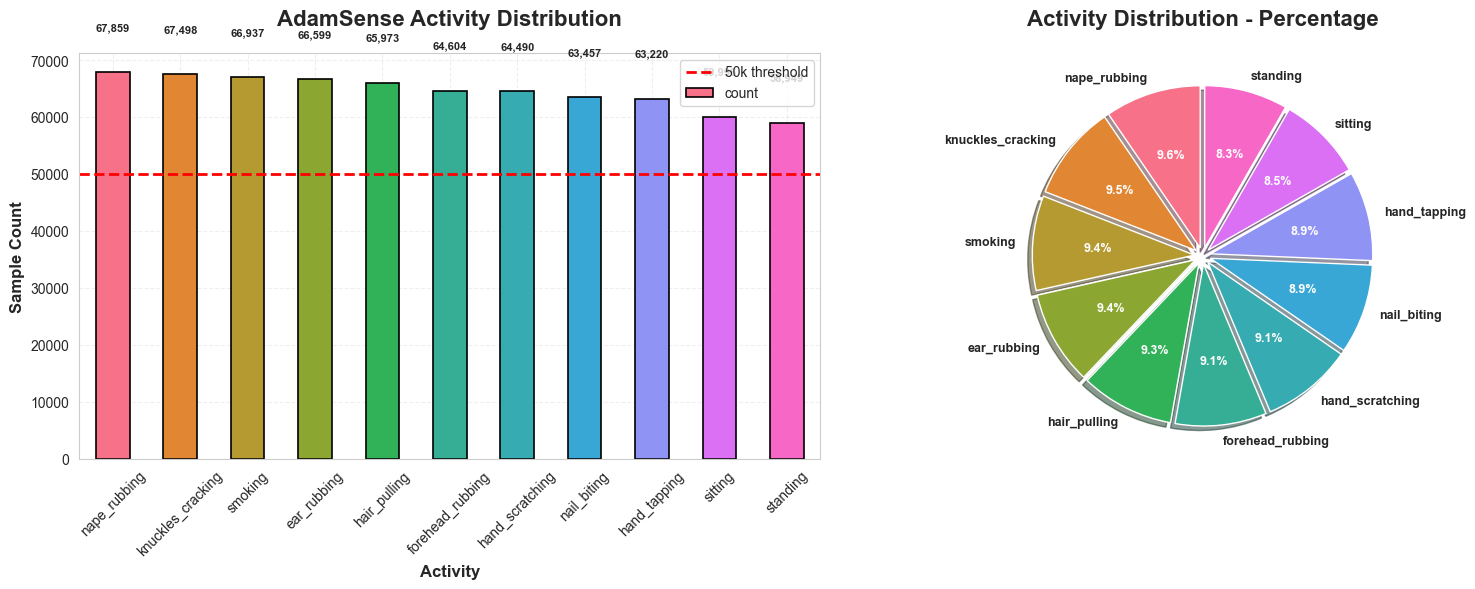


RECOMMENDATION FOR ACTIVITY SELECTION

Activities with ≥50k samples: 11

✓ Good! You have enough activities for training.

Suggested activities to select:
  1. nape_rubbing                   (67,859 samples)
  2. knuckles_cracking              (67,498 samples)
  3. smoking                        (66,937 samples)
  4. ear_rubbing                    (66,599 samples)
  5. hair_pulling                   (65,973 samples)
  6. forehead_rubbing               (64,604 samples)
  7. hand_scratching                (64,490 samples)
  8. nail_biting                    (63,457 samples)
  9. hand_tapping                   (63,220 samples)
  10. sitting                        (59,996 samples)


In [8]:
# Visualize activity distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
colors = sns.color_palette("husl", len(activity_counts))
activity_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('AdamSense Activity Distribution', fontsize=16, weight='bold', pad=20)
axes[0].set_xlabel('Activity', fontsize=12, weight='bold')
axes[0].set_ylabel('Sample Count', fontsize=12, weight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Add 50k threshold line
axes[0].axhline(y=50000, color='red', linestyle='--', linewidth=2, label='50k threshold')
axes[0].legend()

# Add value labels on bars
for i, (activity, count) in enumerate(activity_counts.items()):
    axes[0].text(i, count + (total * 0.01), f'{count:,}', 
                ha='center', va='bottom', fontsize=8, weight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    activity_counts.values, 
    labels=activity_counts.index, 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05] * len(activity_counts),
    shadow=True
)
axes[1].set_title('Activity Distribution - Percentage', fontsize=16, weight='bold', pad=20)

# Enhance text
for text in texts:
    text.set_fontsize(9)
    text.set_weight('bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}activity_distribution.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {OUTPUT_DIR}activity_distribution.png")
plt.show()

# Recommendations
print("\n" + "="*70)
print("RECOMMENDATION FOR ACTIVITY SELECTION")
print("="*70)

sufficient_activities = activity_counts[activity_counts >= 50000]
print(f"\nActivities with ≥50k samples: {len(sufficient_activities)}")
if len(sufficient_activities) >= 5:
    print("\n✓ Good! You have enough activities for training.")
    print("\nSuggested activities to select:")
    for i, (activity, count) in enumerate(sufficient_activities.head(10).items(), 1):
        print(f"  {i}. {activity:<30} ({count:,} samples)")
else:
    print(f"\n⚠️  Only {len(sufficient_activities)} activities have ≥50k samples.")
    print("   Consider lowering threshold or including more activities.")

---
## Step 7: User Distribution Analysis

In [10]:
print("="*70)
print("USER DISTRIBUTION")
print("="*70)

user_counts = df['User'].value_counts().sort_index()
total_users = len(user_counts)

print(f"\nTotal users: {total_users}")
print(f"\nSamples per user statistics:")
print(f"  Minimum:  {user_counts.min():>8,} samples")
print(f"  Maximum:  {user_counts.max():>8,} samples")
print(f"  Mean:     {user_counts.mean():>8,.0f} samples")
print(f"  Median:   {user_counts.median():>8,.0f} samples")
print(f"  Std Dev:  {user_counts.std():>8,.0f} samples")

print(f"\nFirst 15 users:")
print("-"*50)
for i, (user, count) in enumerate(user_counts.head(15).items()):
    pct = count / len(df) * 100
    bar = '▓' * int(pct * 2)
    print(f"  User {user:>3d}: {count:>8,} samples ({pct:>5.2f}%) {bar}")

USER DISTRIBUTION

Total users: 10

Samples per user statistics:
  Minimum:    52,447 samples
  Maximum:   136,406 samples
  Mean:       70,958 samples
  Median:     66,228 samples
  Std Dev:    23,539 samples

First 15 users:
--------------------------------------------------
  User   2:   66,162 samples ( 9.32%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User   3:   60,725 samples ( 8.56%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User   5:   52,447 samples ( 7.39%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User   6:   61,477 samples ( 8.66%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User   7:   68,480 samples ( 9.65%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User   8:   61,014 samples ( 8.60%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User  10:   69,274 samples ( 9.76%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User  14:   67,304 samples ( 9.49%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User  15:   66,293 samples ( 9.34%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  User  16:  136,406 samples (19.22%) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓



✓ Saved: ./exploration_outputs/user_distribution.png


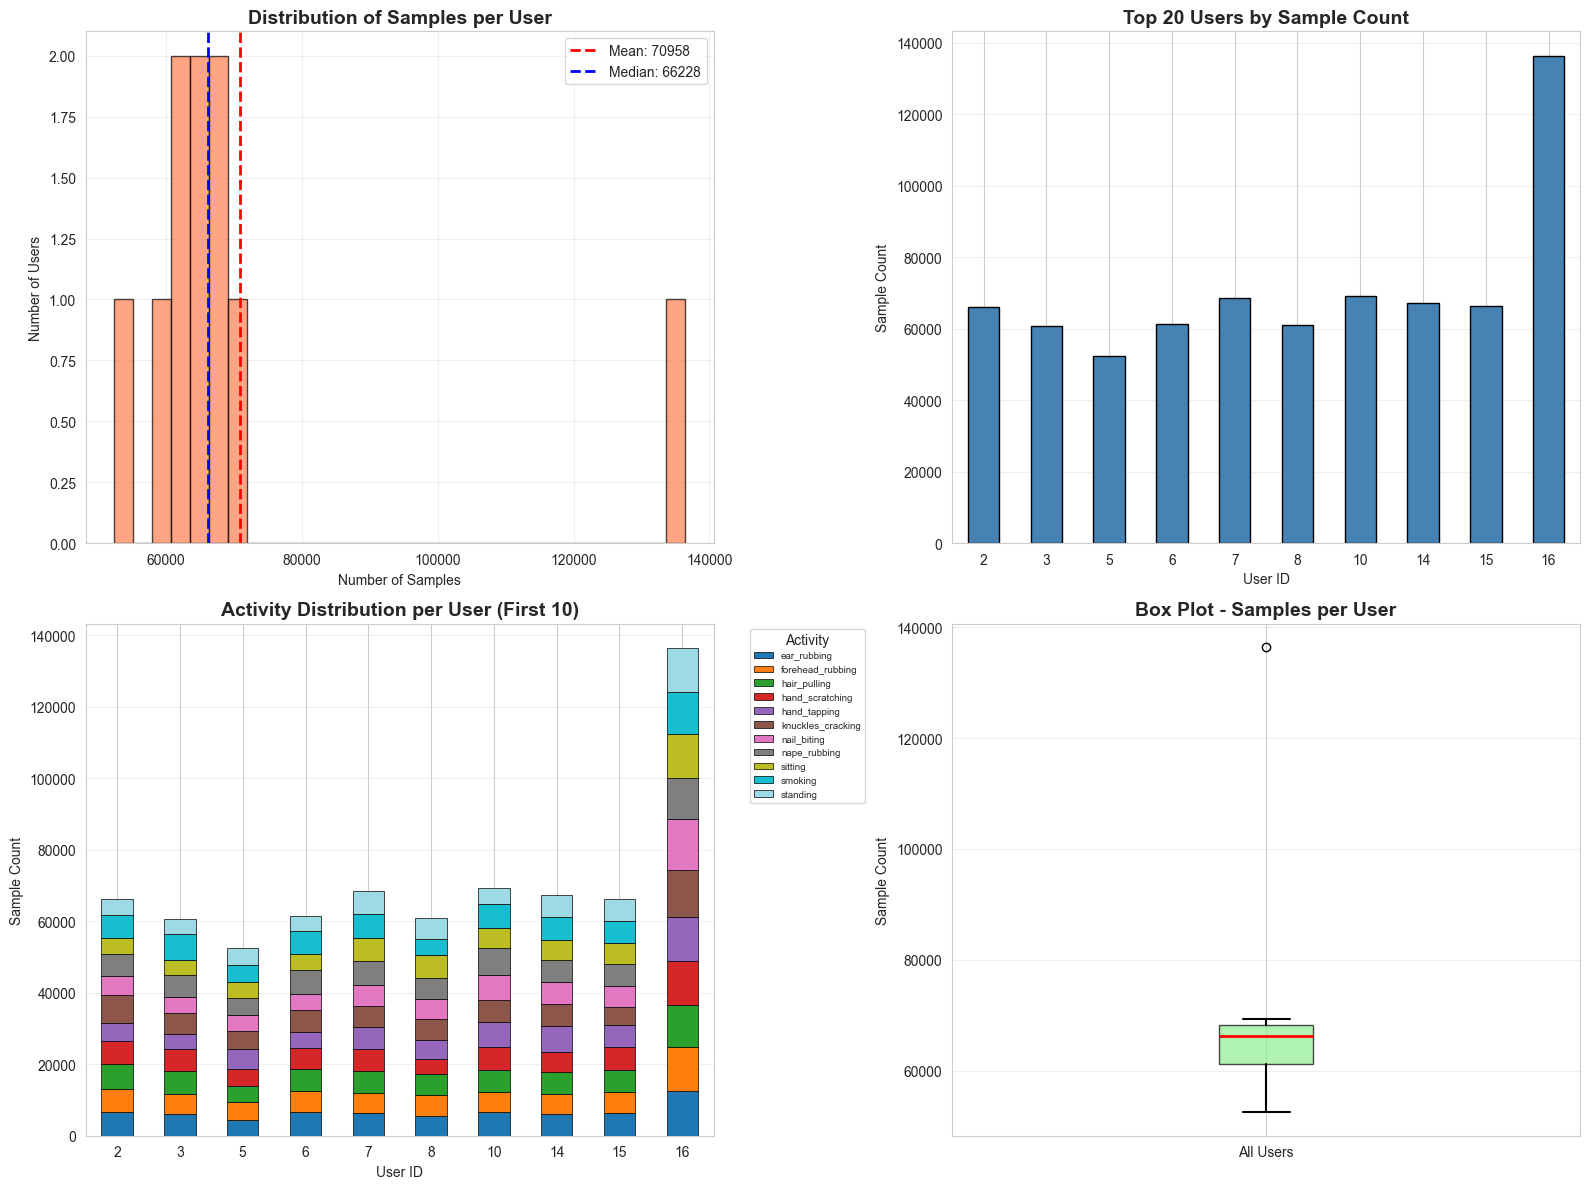

In [11]:
# Visualize user distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram
axes[0, 0].hist(user_counts.values, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(user_counts.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {user_counts.mean():.0f}')
axes[0, 0].axvline(user_counts.median(), color='blue', linestyle='--', linewidth=2, 
                   label=f'Median: {user_counts.median():.0f}')
axes[0, 0].set_title('Distribution of Samples per User', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Number of Samples')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Top 20 users bar plot
user_counts.head(20).plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Top 20 Users by Sample Count', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('User ID')
axes[0, 1].set_ylabel('Sample Count')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Activity distribution per user (first 10)
activity_user_crosstab = pd.crosstab(df['User'], df['Activity'])
activity_user_crosstab.head(10).plot(
    kind='bar', stacked=True, ax=axes[1, 0], 
    colormap='tab20', edgecolor='black', linewidth=0.5
)
axes[1, 0].set_title('Activity Distribution per User (First 10)', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('User ID')
axes[1, 0].set_ylabel('Sample Count')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Box plot
axes[1, 1].boxplot([user_counts.values], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
axes[1, 1].set_title('Box Plot - Samples per User', fontsize=14, weight='bold')
axes[1, 1].set_ylabel('Sample Count')
axes[1, 1].set_xticklabels(['All Users'])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}user_distribution.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {OUTPUT_DIR}user_distribution.png")
plt.show()

---
## Step 8: Wrist Sensor Statistics

In [12]:
print("="*70)
print("WRIST SENSOR DATA STATISTICS")
print("="*70)

print("\nSensor channels: 6 (Accelerometer + Gyroscope)")
print("Target hardware: Arduino Nano 33 BLE Sense (no magnetometer)")

print("\nDetailed Statistics:")
print("-"*85)
print(f"{'Sensor':<10} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12} {'Range':>12}")
print("-"*85)

for sensor in wrist_sensors:
    mean = df[sensor].mean()
    std = df[sensor].std()
    min_val = df[sensor].min()
    max_val = df[sensor].max()
    range_val = max_val - min_val
    
    print(f"{sensor:<10} {mean:>12.4f} {std:>12.4f} {min_val:>12.4f} {max_val:>12.4f} {range_val:>12.4f}")

print("-"*85)

# Data quality checks
print("\nData Quality Checks:")

# Missing values
missing = df[wrist_sensors].isnull().sum()
if missing.sum() == 0:
    print("  ✓ No missing values detected!")
else:
    print("  ⚠️  Missing values detected:")
    for sensor, count in missing.items():
        if count > 0:
            pct = count / len(df) * 100
            print(f"    {sensor}: {count:,} ({pct:.2f}%)")

# Infinite values
infinite = df[wrist_sensors].apply(lambda x: np.isinf(x).sum())
if infinite.sum() == 0:
    print("  ✓ No infinite values detected!")
else:
    print("  ⚠️  Infinite values detected:")
    for sensor, count in infinite.items():
        if count > 0:
            print(f"    {sensor}: {count:,}")

# Zero variance check
print("\n  Sensor variance check:")
for sensor in wrist_sensors:
    var = df[sensor].var()
    if var < 0.001:
        print(f"    ⚠️  {sensor}: Very low variance ({var:.6f})")
    else:
        print(f"    ✓ {sensor}: Good variance ({var:.4f})")

WRIST SENSOR DATA STATISTICS

Sensor channels: 6 (Accelerometer + Gyroscope)
Target hardware: Arduino Nano 33 BLE Sense (no magnetometer)

Detailed Statistics:
-------------------------------------------------------------------------------------
Sensor             Mean          Std          Min          Max        Range
-------------------------------------------------------------------------------------
Ax_w             0.2268       0.5803      -2.0000       2.0000       4.0000
Ay_w             0.0581       0.4989      -2.0000       2.0000       4.0000
Az_w            -0.4574       0.3893      -2.0000       2.0000       4.0000
Gx_w            -0.9104      48.4622    -786.1600     783.3500    1569.5100
Gy_w             1.7283      23.6856    -401.9500     439.2700     841.2200
Gz_w             0.0776      20.9750    -508.9000     572.0100    1080.9100
-------------------------------------------------------------------------------------

Data Quality Checks:
  ✓ No missing values detect


✓ Saved: ./exploration_outputs/sensor_distributions.png


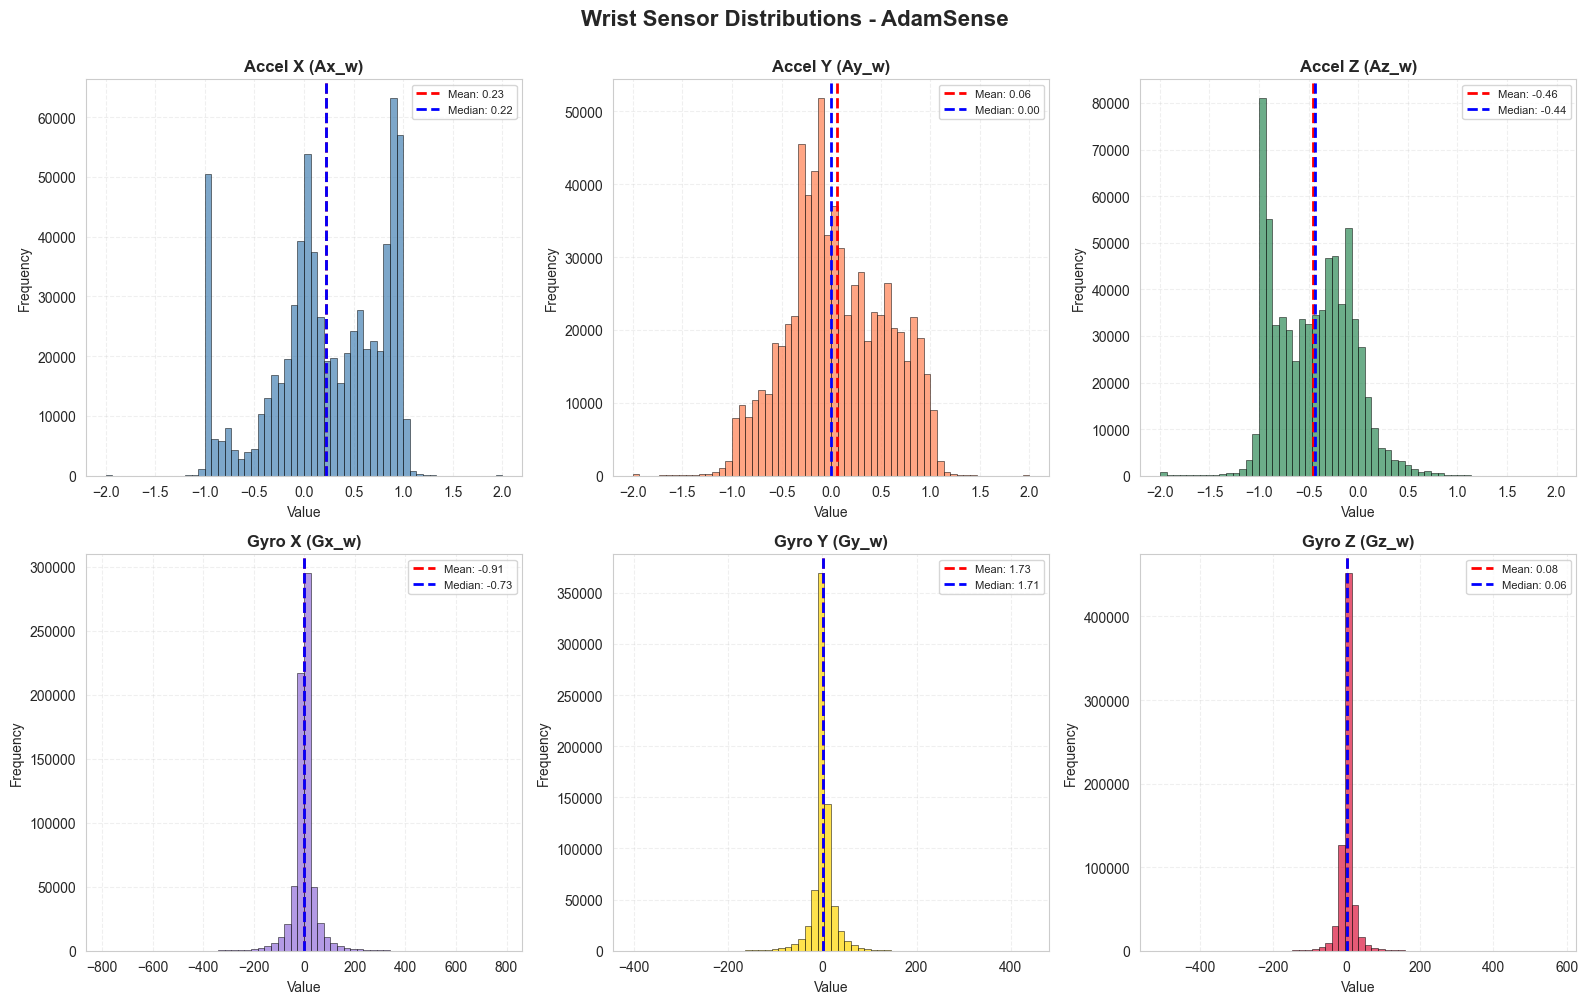

In [13]:
# Visualize sensor distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'gold', 'crimson']
sensor_names = ['Accel X', 'Accel Y', 'Accel Z', 'Gyro X', 'Gyro Y', 'Gyro Z']

for i, (sensor, name, color) in enumerate(zip(wrist_sensors, sensor_names, colors)):
    # Histogram
    axes[i].hist(df[sensor].dropna(), bins=60, color=color, edgecolor='black', alpha=0.7, linewidth=0.5)
    
    # Add mean and median lines
    mean_val = df[sensor].mean()
    median_val = df[sensor].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    
    axes[i].set_title(f'{name} ({sensor})', fontsize=12, weight='bold')
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Wrist Sensor Distributions - AdamSense', fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}sensor_distributions.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {OUTPUT_DIR}sensor_distributions.png")
plt.show()

---
## Step 9: SAMPLING RATE CALCULATION - CRITICAL!

In [17]:
print("="*70)
print("SAMPLING RATE - FROM DOCUMENTATION")
print("="*70)

# According to AdamSense documentation (page 5, section 8, point 5):
# "The sample rate for smart phone and IMU both is kept 50Hz"

final_sampling_rate = 50 

print("\n✓ OFFICIAL SAMPLING RATE: 50 Hz")

print("\n" + "="*70)
print("WINDOW SIZE CALCULATIONS")
print("="*70)

print(f"\nAt 50 Hz sampling rate:")
print("-"*70)

durations = [2.0, 2.5, 3.0, 4.0]
for duration in durations:
    samples = int(50 * duration)
    power_of_2 = 2 ** round(np.log2(samples))
    print(f"  {duration}s = {samples:>3d} samples ≈ {power_of_2:>3d} samples (power of 2)")

recommended_window = 128
print(f"\n RECOMMENDED: {recommended_window} samples")
print(f"   Duration: {recommended_window/50:.2f} seconds")
print(f"   Matches your StressSense setup!")

print("\n" + "="*70)
print("DATA COLLECTION DETAILS")
print("="*70)

print("\nFrom documentation:")
print(f"  • Sampling rate: 50 Hz")
print(f"  • Duration per activity: ~2 minutes")
print(f"  • Total subjects: 10")
print(f"  • Total activities: 11")
print(f"  • Total instances: 709,582")
print(f"  • Sensors: SparkFun 9DoF Razor IMU M0")

print("\n" + "="*70)

SAMPLING RATE - FROM DOCUMENTATION

✓ OFFICIAL SAMPLING RATE: 50 Hz

WINDOW SIZE CALCULATIONS

At 50 Hz sampling rate:
----------------------------------------------------------------------
  2.0s = 100 samples ≈ 128 samples (power of 2)
  2.5s = 125 samples ≈ 128 samples (power of 2)
  3.0s = 150 samples ≈ 128 samples (power of 2)
  4.0s = 200 samples ≈ 256 samples (power of 2)

 RECOMMENDED: 128 samples
   Duration: 2.56 seconds
   Matches your StressSense setup!

DATA COLLECTION DETAILS

From documentation:
  • Sampling rate: 50 Hz
  • Duration per activity: ~2 minutes
  • Total subjects: 10
  • Total activities: 11
  • Total instances: 709,582
  • Sensors: SparkFun 9DoF Razor IMU M0



In [18]:
# Calculate recommended window sizes
print("\n" + "="*70)
print("RECOMMENDED WINDOW SIZES")
print("="*70)

print(f"\nUsing sampling rate: {final_sampling_rate:.0f} Hz")
print("\nWindow calculations:")
print("-"*70)
print(f"{'Duration':>12} {'Samples':>12} {'Power of 2':>15} {'Recommended?':>15}")
print("-"*70)

durations = [2.0, 2.5, 3.0, 4.0, 5.0]
recommended_window = None

for duration in durations:
    samples = int(final_sampling_rate * duration)
    # Find nearest power of 2
    power_of_2 = 2 ** round(np.log2(samples))
    
    # Recommend 2.5-3 second windows
    is_recommended = '✓' if 2.5 <= duration <= 3.0 else ''
    
    print(f"{duration:>11.1f}s {samples:>12d} {power_of_2:>15d} {is_recommended:>15}")
    
    if 2.5 <= duration <= 3.0 and recommended_window is None:
        recommended_window = power_of_2

print("-"*70)

if recommended_window is None:
    recommended_window = 2 ** round(np.log2(final_sampling_rate * 2.5))

print(f"\n✅ RECOMMENDED WINDOW SIZE: {recommended_window} samples")
print(f"   → Duration: ~{recommended_window/final_sampling_rate:.2f} seconds")
print(f"   → Use this in your preprocessing CONFIG!")

print("\n" + "="*70)


RECOMMENDED WINDOW SIZES

Using sampling rate: 50 Hz

Window calculations:
----------------------------------------------------------------------
    Duration      Samples      Power of 2    Recommended?
----------------------------------------------------------------------
        2.0s          100             128                
        2.5s          125             128               ✓
        3.0s          150             128               ✓
        4.0s          200             256                
        5.0s          250             256                
----------------------------------------------------------------------

✅ RECOMMENDED WINDOW SIZE: 128 samples
   → Duration: ~2.56 seconds
   → Use this in your preprocessing CONFIG!



---
## Step 10: Visualize Activity Patterns

ACTIVITY SENSOR PATTERNS

Visualizing 6 activities...

✓ Saved: ./exploration_outputs/activity_patterns.png


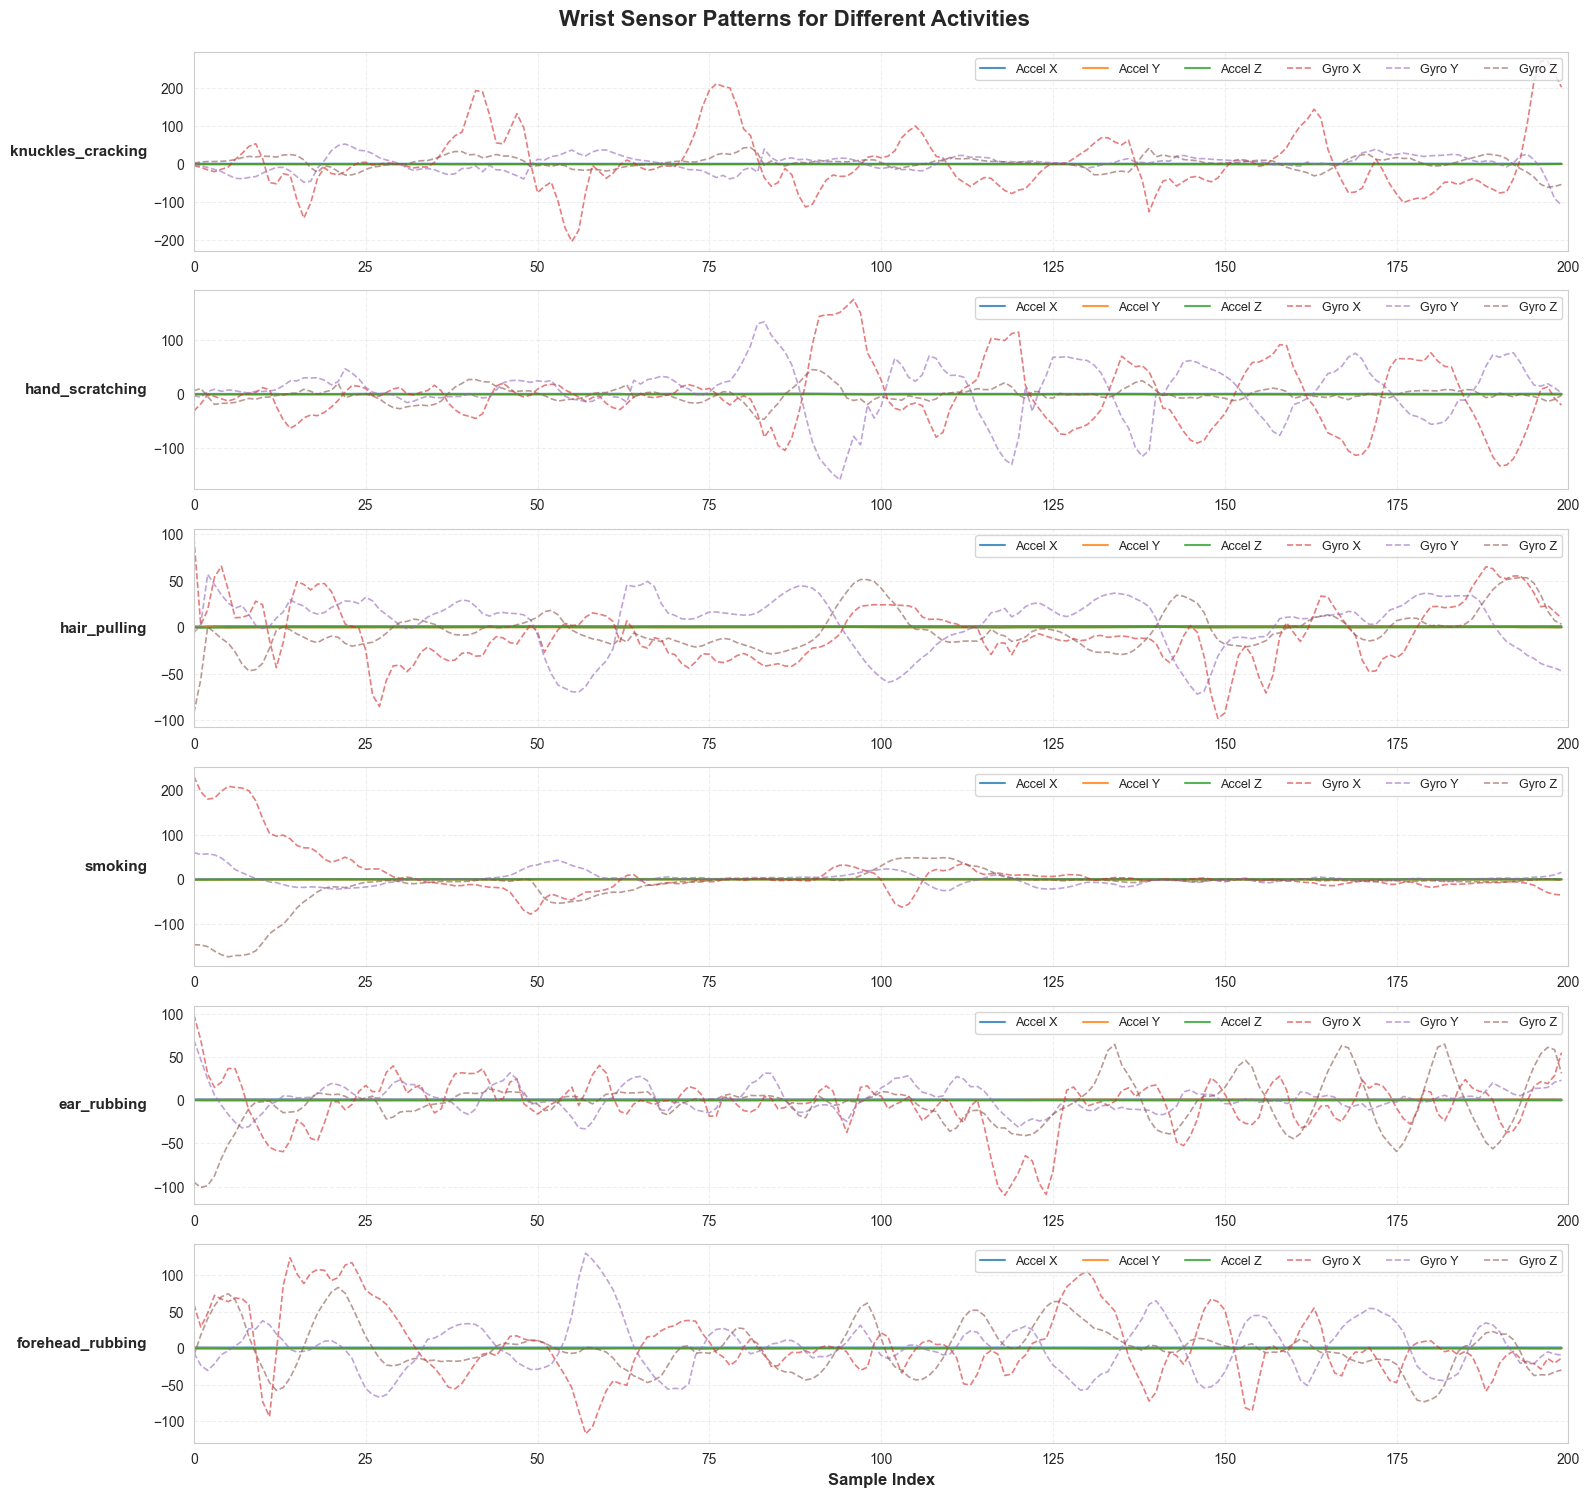

In [19]:
print("="*70)
print("ACTIVITY SENSOR PATTERNS")
print("="*70)

# Select up to 6 activities for visualization
unique_activities = df['Activity'].unique()[:6]
n_activities = len(unique_activities)

print(f"\nVisualizing {n_activities} activities...")

fig, axes = plt.subplots(n_activities, 1, figsize=(16, n_activities * 2.5))
if n_activities == 1:
    axes = [axes]

sample_size = 200  # samples to plot

for i, activity in enumerate(unique_activities):
    activity_data = df[df['Activity'] == activity].head(sample_size)
    
    # Plot all 6 channels
    axes[i].plot(activity_data['Ax_w'].values, label='Accel X', alpha=0.8, linewidth=1.5, color='#1f77b4')
    axes[i].plot(activity_data['Ay_w'].values, label='Accel Y', alpha=0.8, linewidth=1.5, color='#ff7f0e')
    axes[i].plot(activity_data['Az_w'].values, label='Accel Z', alpha=0.8, linewidth=1.5, color='#2ca02c')
    axes[i].plot(activity_data['Gx_w'].values, label='Gyro X', alpha=0.6, linewidth=1.2, linestyle='--', color='#d62728')
    axes[i].plot(activity_data['Gy_w'].values, label='Gyro Y', alpha=0.6, linewidth=1.2, linestyle='--', color='#9467bd')
    axes[i].plot(activity_data['Gz_w'].values, label='Gyro Z', alpha=0.6, linewidth=1.2, linestyle='--', color='#8c564b')
    
    axes[i].set_ylabel(activity, fontsize=11, weight='bold', rotation=0, ha='right', va='center')
    axes[i].legend(loc='upper right', fontsize=9, ncol=6)
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_xlim(0, sample_size)

axes[-1].set_xlabel('Sample Index', fontsize=12, weight='bold')
plt.suptitle('Wrist Sensor Patterns for Different Activities', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}activity_patterns.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {OUTPUT_DIR}activity_patterns.png")
plt.show()

---
## Step 11: Correlation Analysis

SENSOR CORRELATION ANALYSIS

Correlation matrix:


,Ax_w,Ay_w,Az_w,Gx_w,Gy_w,Gz_w
Ax_w,1.000000,-0.063813,0.186915,-0.001493,0.013950,-0.007483
Ay_w,-0.063813,1.000000,-0.035296,-0.011012,0.007248,0.024894
Az_w,0.186915,-0.035296,1.000000,-0.003357,-0.001931,0.018278
Gx_w,-0.001493,-0.011012,-0.003357,1.000000,-0.052257,-0.200343
Gy_w,0.013950,0.007248,-0.001931,-0.052257,1.000000,-0.076183
Gz_w,-0.007483,0.024894,0.018278,-0.200343,-0.076183,1.000000



✓ Saved: ./exploration_outputs/correlation_matrix.png


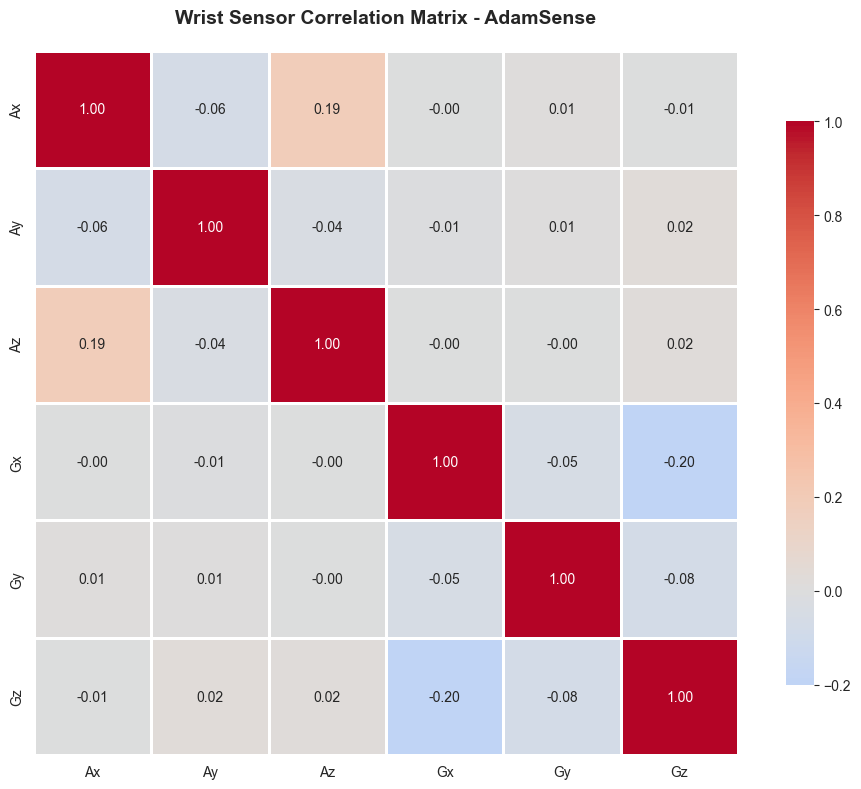


Highly correlated sensor pairs (|r| > 0.7):
  None found (good - sensors are independent)


In [20]:
print("="*70)
print("SENSOR CORRELATION ANALYSIS")
print("="*70)

# Calculate correlation matrix
corr_matrix = df[wrist_sensors].corr()

print("\nCorrelation matrix:")
display(corr_matrix)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            xticklabels=['Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz'],
            yticklabels=['Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz'])
plt.title('Wrist Sensor Correlation Matrix - AdamSense', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}correlation_matrix.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {OUTPUT_DIR}correlation_matrix.png")
plt.show()

# Find highly correlated pairs
print("\nHighly correlated sensor pairs (|r| > 0.7):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    for sensor1, sensor2, corr_val in high_corr:
        print(f"  {sensor1} <-> {sensor2}: {corr_val:.3f}")
else:
    print("  None found (good - sensors are independent)")

---
## Step 12: FINAL SUMMARY REPORT

In [21]:
print("\n" + "="*70)
print("ADAMSENSE EXPLORATION - FINAL SUMMARY")
print("="*70)

print("\n📊 DATASET STATISTICS")
print("-"*70)
print(f"  Total samples:      {len(df):>12,}")
print(f"  Total activities:   {len(activity_counts):>12}")
print(f"  Total users:        {len(user_counts):>12}")
print(f"  Memory usage:       {df.memory_usage(deep=True).sum() / 1e6:>11.1f} MB")

print("\n🎯 SENSOR CONFIGURATION")
print("-"*70)
print(f"  Sensor channels:    {len(wrist_sensors)} (Accel + Gyro)")
print(f"  Accelerometer:      Ax_w, Ay_w, Az_w")
print(f"  Gyroscope:          Gx_w, Gy_w, Gz_w")
print(f"  Magnetometer:       NOT USED (hardware limitation)")
print(f"  Missing values:     {df[wrist_sensors].isnull().sum().sum()}")

print("\n⏱️  SAMPLING RATE")
print("-"*70)
print(f"  Calculated rate:    {final_sampling_rate:>11.1f} Hz")
print(f"  Recommended window: {recommended_window:>12} samples")
print(f"  Window duration:    {recommended_window/final_sampling_rate:>11.2f} seconds")

print("\n📁 ACTIVITY SELECTION")
print("-"*70)
sufficient = activity_counts[activity_counts >= 50000]
print(f"  Activities with ≥50k samples: {len(sufficient)}")
if len(sufficient) >= 5:
    print(f"\n  ✓ Top {min(10, len(sufficient))} recommended activities:")
    for i, (activity, count) in enumerate(sufficient.head(10).items(), 1):
        print(f"    {i:2d}. {activity:<30} ({count:>7,} samples)")
else:
    print(f"\n  ⚠️  Only {len(sufficient)} activities have sufficient samples")

print("\n📈 DATA BALANCE")
print("-"*70)
print(f"  Most common:        {activity_counts.index[0]} ({activity_counts.iloc[0]:,})")
print(f"  Least common:       {activity_counts.index[-1]} ({activity_counts.iloc[-1]:,})")
print(f"  Imbalance ratio:    {activity_counts.iloc[0] / activity_counts.iloc[-1]:>11.2f}x")

print("\n📄 GENERATED FILES")
print("-"*70)
output_files = [
    'activity_distribution.png',
    'user_distribution.png',
    'sensor_distributions.png',
    'activity_patterns.png',
    'correlation_matrix.png'
]
for f in output_files:
    print(f"  ✓ {OUTPUT_DIR}{f}")

print("\n" + "="*70)
print("✅ EXPLORATION COMPLETE!")
print("="*70)

print("\n📋 NEXT STEPS:")
print("-"*70)
print("  1. Select 5-10 activities from the recommended list above")
print(f"  2. Note the sampling rate: {final_sampling_rate:.0f} Hz")
print(f"  3. Note the window size: {recommended_window} samples")
print("  4. Update your preprocessing config with these values")
print("  5. Run adamsense_preprocessing.py to preprocess the data")
print("  6. Train your IDCNN model (same architecture, 6 features)")

print("\n💾 SAVE THESE VALUES:")
print("-"*70)
print(f"  CONFIG['sampling_rate'] = {final_sampling_rate:.0f}")
print(f"  CONFIG['window_size'] = {recommended_window}")
print(f"  CONFIG['sensor_columns'] = {wrist_sensors}")

print("\n" + "="*70)


ADAMSENSE EXPLORATION - FINAL SUMMARY

📊 DATASET STATISTICS
----------------------------------------------------------------------
  Total samples:           709,582
  Total activities:             11
  Total users:                  10
  Memory usage:             264.5 MB

🎯 SENSOR CONFIGURATION
----------------------------------------------------------------------
  Sensor channels:    6 (Accel + Gyro)
  Accelerometer:      Ax_w, Ay_w, Az_w
  Gyroscope:          Gx_w, Gy_w, Gz_w
  Magnetometer:       NOT USED (hardware limitation)
  Missing values:     0

⏱️  SAMPLING RATE
----------------------------------------------------------------------
  Calculated rate:           50.0 Hz
  Recommended window:          128 samples
  Window duration:           2.56 seconds

📁 ACTIVITY SELECTION
----------------------------------------------------------------------
  Activities with ≥50k samples: 11

  ✓ Top 10 recommended activities:
     1. nape_rubbing                   ( 67,859 samples)
    